In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression , Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [4]:
df = pd.read_csv('data/stud.csv')

In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
x = df.drop('math score' , axis = 1)

In [8]:
y = df['math score']

In [9]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [10]:
cat_features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
num_features = ['writing score' , 'reading score']

In [11]:
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer


numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()
preprocessor = ColumnTransformer([
    ("OneHotEncoder" , oh_transformer , cat_features),
    ("StandardScaler" , numeric_transformer , num_features),
])

In [12]:
X = preprocessor.fit_transform(x)

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

CREATING AN EVALUTION FUNCTION

In [14]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true , predicted)
    mse = mean_squared_error(true , predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true , predicted)
    return mae , mse , rmse , r2

In [15]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "K-Neighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor(),
    "XGBRegressor" : XGBRegressor(),
    "CatBoosting Regressor" : CatBoostRegressor(verbose = False),
    "AdaBoost Regressor" : AdaBoostRegressor()
}
model_list = []
r2_list = []


for model_name , model in models.items():
    model.fit(X_train , y_train)
    y_pred = model.predict(X_test)
    mae , mse , rmse , r2 = evaluate_model(y_test , y_pred)
    model_list.append(model_name)
    r2_list.append(r2)

d:\MLProject\venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\MLProject\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "d:\MLProject\venv\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\MLProject\venv\lib\subprocess.py", line 854, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\MLProject\venv\lib\subprocess.py", line 1307, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


In [16]:
result =pd.DataFrame(list(zip(model_list , r2_list)),columns = ['model name' , 'r2 score']).sort_values(by = ['r2 score'] , ascending = False)

In [17]:
result

,model name,r2 score
2,Ridge,0.880593
0,Linear Regression,0.880111
7,CatBoosting Regressor,0.851748
5,Random Forest Regressor,0.851573
8,AdaBoost Regressor,0.842161
6,XGBRegressor,0.828454
1,Lasso,0.825315
3,K-Neighbors Regressor,0.783754
4,Decision Tree,0.740567


GOING WITH LINEAR REGRESSION

In [18]:
lin_model = LinearRegression()
lin_model.fit(X_train , y_train)

LinearRegression()

In [19]:
y_pred = lin_model.predict(X_test)
score = r2_score(y_test , y_pred)*100

Text(0, 0.5, 'Predicted')

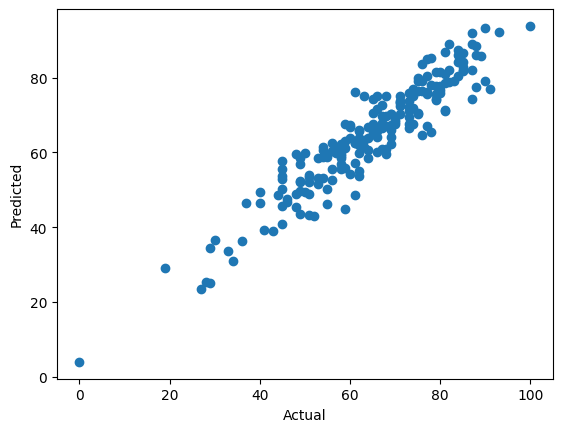

In [20]:
plt.scatter(x = y_test , y = y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')